In [1]:
# calculate and compare rates from different methods

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import scipy.integrate as integrate

import analysis.utils as utils # here's rate calculation functions
import analysis.plotter as plotter
import analysis.config as config

import math

In [3]:
# todo: v_E is actually a function of time: v_E = 244 + 15* np.sin(2*np.pi*y) km/s
def velo_distributions(v):
    return np.exp(-(v+config.v_E)**2/config.v_0**2)
def velo_integrant(v):
    return 4*np.pi*v**2*np.exp(-(v+config.v_E)**2/config.v_0**2)
# normalization factor
k = integrate.quad(velo_integrant, 0, config.v_esc)[0]

In [4]:
# # this is dR/dE_R
# def differential_spectrum(E_R):
#     R_0 = 540./config.A/m_D*xs*1*(config.v_0/230) 
#     E_0 = 1/2*m_D*(config.v_0)**2
#     m_T = config.A*0.938 
#     r = 4*(m_D*m_T)/(m_D+m_T)**2
#     def integrant(v):
#         return 1/v * velo_distributions(v) * 4* np.pi * v**2
#     # v_min = np.sqrt(2*E_R/r/m_D)-config.v_E
#     v_min = np.sqrt(E_R/r/E_0)*config.v_0
#     v_max = config.v_esc
#     print(r,v_min, v_max, config.v_esc)
#     # print("int", integrate.quad(integrant, v_min, v_max)[0])
#     # print("diff_sepc", R_0/E_0/r/(2*np.pi*config.v_0**2) * integrate.quad(integrant, v_min, v_max)[0])
#     return R_0/E_0/r/(2*np.pi*config.v_0**2) * integrate.quad(integrant, v_min, v_max)[0]
    
# def differential_spectrum_after_corrections(E_R):
#     # nuclear form factor
#     F = np.exp(-1/3*(6.92*10**-3)**2*config.A*((1.14*config.A)**1/3)**2)
#     return differential_spectrum(E_R) * config.A**2 * F

# def get_spectrum_from_numerical():

#     return differential_spectrum_after_corrections

# #this cell didn't give correct result...

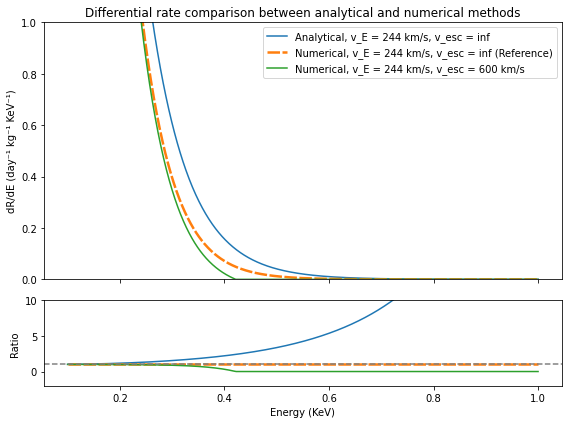

0.8207207207207207 0.000534961033034526 3.135603921881996e-05


In [15]:
# function test, compare with the next cell
# Generate energy range in GeV and convert to KeV
E_Rs_GeV = np.linspace(0.1*1e-6, 1e-6 * 1, 1000)

# Compute differential rates and normalize
# divide by A^2 because don't consider interaction factor here, 
# that is, xs = xs per nucleus (only to compare with previous results)
dRs0 = [utils.get_spectrum_in_GeV_analytical(E)/config.A**2 for E in E_Rs_GeV]
dRs1 = [utils.get_spectrum_in_GeV_numerical(E)/config.A**2 for E in E_Rs_GeV]
# v.esc= inf.
config.update_constants(v_esc=999999.)
dRs2 = [utils.get_spectrum_in_GeV_numerical(E)/config.A**2 for E in E_Rs_GeV]
config.reset_constants()

plotter.plot_differential_rate_with_ratio(
    E_Rs_GeV,
    [dRs0, dRs2, dRs1],
    labels=[
        "Analytical, v_E = 244 km/s, v_esc = inf",
        "Numerical, v_E = 244 km/s, v_esc = inf",
        "Numerical, v_E = 244 km/s, v_esc = 600 km/s"
    ],
    reference_index=1,
    unit_conversion=True,
    panel_rage=[-2, 10],
    title="Differential rate comparison between analytical and numerical methods",
)

# print(np.array(dRs0[90:])/np.array(dRs2[90:]))

print(E_Rs_GeV[800]*1e6, dRs0[800]*1e-6, dRs2[800]*1e-6)

In [6]:
# keep this cell for comparison or sanity check of refactored function
# # Define conversion factor
# GeV_to_KeV = 1e6  # 1 GeV = 10^6 KeV

# # Generate energy range in GeV and convert to KeV
# E_Rs_GeV = np.linspace(0.1e-6, 0.1e-6 * 5, 1000)
# E_Rs_KeV = E_Rs_GeV * GeV_to_KeV

# # Compute differential rates and normalize
# dRs0 = [get_spectrum(E) / config.A**2 for E in E_Rs_GeV]
# dRs1 = [differential_spectrum(E) / config.A**2 for E in E_Rs_GeV]

# # v.esc= inf.
# config.update_constants(v_esc=999999.)
# dRs2 = [differential_spectrum(E) / config.A**2 for E in E_Rs_GeV]
# config.reset_constants()

# # Update for v_E = 200 km/s
# config.update_constants(v_E=200.0)
# dRs3 = [differential_spectrum(E) / config.A**2 for E in E_Rs_GeV]
# config.reset_constants()

# # Convert dR/dE to KeV-1
# dRs0_KeV = np.array(dRs0) / GeV_to_KeV
# dRs1_KeV = np.array(dRs1) / GeV_to_KeV
# dRs2_KeV = np.array(dRs2) / GeV_to_KeV
# dRs3_KeV = np.array(dRs3) / GeV_to_KeV

# # Compute ratios relative to dRs1_KeV (numerical, v_E = 244 km/s, v_esc = 600 km/s)
# ratio_0 = np.divide(dRs0_KeV, dRs1_KeV, where=dRs1_KeV != 0)
# ratio_1 = np.divide(dRs1_KeV, dRs1_KeV, where=dRs1_KeV != 0)
# ratio_2 = np.divide(dRs2_KeV, dRs1_KeV, where=dRs1_KeV != 0)
# ratio_3 = np.divide(dRs3_KeV, dRs1_KeV, where=dRs1_KeV != 0)



# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1.5]})

# # --- Main panel ---
# ax[0].plot(E_Rs_KeV, dRs0_KeV, label="analytical, v_E = 244 km/s, v_esc = inf")
# ax[0].plot(E_Rs_KeV, dRs1_KeV, label="numerical, v_E = 244 km/s, v_esc = 600 km/s")
# ax[0].plot(E_Rs_KeV, dRs2_KeV, label="numerical, v_E = 244 km/s, v_esc = inf")
# ax[0].plot(E_Rs_KeV, dRs3_KeV, label="numerical, v_E = 200 km/s, v_esc = 600 km/s")

# ax[0].set_ylabel("dR/dE (day⁻¹ kg⁻¹ KeV⁻¹)")
# ax[0].set_title("Differential Rate")
# ax[0].legend()

# # --- Ratio panel ---
# ax[1].plot(E_Rs_KeV, ratio_0, label="analytical / numerical")
# ax[1].plot(E_Rs_KeV, ratio_1)
# ax[1].plot(E_Rs_KeV, ratio_2, label="numerical (v_esc = inf) / numerical")
# ax[1].plot(E_Rs_KeV, ratio_3, label="numerical (v_E = 200) / numerical")

# ax[1].set_xlabel("Energy (KeV)")
# ax[1].set_ylabel("Ratio to numerical (244, 600)")
# ax[1].set_ylim(0.5,1.5)
# ax[1].legend()



# # Show the plot
# plt.tight_layout()
# plt.show()



In [7]:
# normalize as in paper
m_D = config.m_D_0
xs = config.xs_0
E0 = 1/2 * m_D * (config.v_0/(3*10**5))**2 # in GeV # 2.93e-07
m_T = config.A*0.938
r = 4*m_D*m_T/(m_D+m_T)**2 # 0.1413
R_0 = 540/(config.A*m_D)*(xs)*1*(config.v_0/230) #1.9285

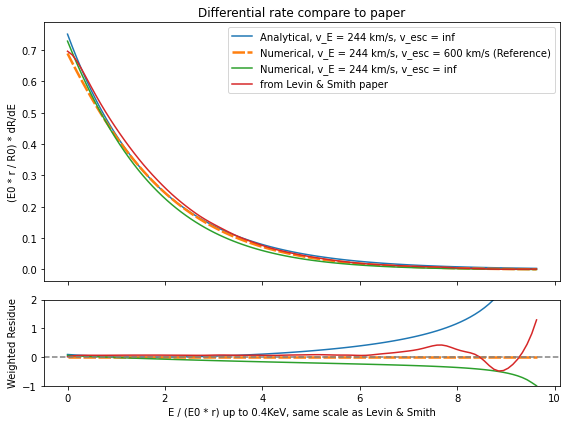

In [8]:
E_Rs = np.linspace(0, 0.4*1e-6 , 100)
dRs0 = np.vectorize(utils.get_spectrum_in_GeV_analytical)(E_Rs)
dRs1 = np.vectorize(utils.get_spectrum_in_GeV_numerical)(E_Rs)
config.update_constants(v_E=219.0)
dRs2 = np.vectorize(utils.get_spectrum_in_GeV_numerical)(E_Rs)
config.reset_constants()
# normalize energy
E_scaled = E_Rs / (E0 * r)
# Normalize rate by (E0 * r / R_0) / A^2 

# in paper the interaction factor ~A^2 is not included yet
from scipy.ndimage import gaussian_filter1d
norm_factor = (E0 * r / R_0) / config.A**2
dRs0_norm, dRs1_norm, dRs2_norm = [dRs * norm_factor for dRs in (dRs0, dRs1, dRs2)]
# add line from the paper, interpolate and smooth
line_from_paper = np.loadtxt("Levin_fig2.csv", delimiter=",") 
x_paper, y_paper = line_from_paper[:,0], line_from_paper[:,1]
interpolation_function = interp1d(x_paper, y_paper, kind='linear', bounds_error=False, fill_value="extrapolate")
y_interpolated = interpolation_function(E_scaled)
y_smooth = gaussian_filter1d(y_interpolated, sigma=2)


plotter.plot_differential_rate_with_residuals(
    E_scaled,
    [dRs0_norm, dRs1_norm, dRs2_norm, y_smooth],
    labels=[
        "Analytical, v_E = 244 km/s, v_esc = inf",
        "Numerical, v_E = 244 km/s, v_esc = 600 km/s",
        "Numerical, v_E = 244 km/s, v_esc = inf",
        "from Levin & Smith paper"
    ],
    reference_index=1,
    title="Differential rate compare to paper",
    panel_rage=(-1, 2),
    unit_conversion=False,
    xlabel="E / (E0 * r) up to 0.4KeV, same scale as Levin & Smith",
    ylabel="(E0 * r / R0) * dR/dE"
)



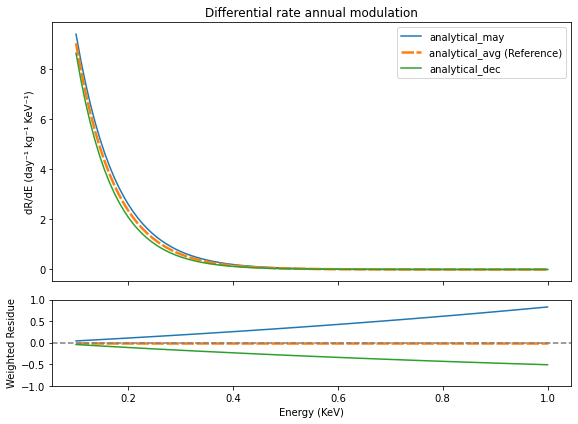

In [9]:
E_Rs_GeV = np.linspace(0.1*1e-6, 1e-6, 100)

# Compute differential rates
config.reset_constants()
# dRs00 = R_0 / E0 / r * np.exp(-E_Rs_GeV / E0 / r)
dRs0 = np.array([utils.get_spectrum_in_GeV_analytical(E) for E in E_Rs_GeV]) / config.A**2
config.update_constants(c1=0.734, c2=0.535)
dRs1 = np.array([utils.get_spectrum_in_GeV_analytical(E) for E in E_Rs_GeV]) / config.A**2
config.update_constants(c1=0.774, c2=0.592)
dRs2 = np.array([utils.get_spectrum_in_GeV_analytical(E) for E in E_Rs_GeV]) / config.A**2
config.reset_constants()  # Ensure default state


plotter.plot_differential_rate_with_residuals(
    E_Rs_GeV,
    [dRs1, dRs0, dRs2],  
    labels=[
        "analytical_may",
        "analytical_avg",
        "analytical_dec"
    ],
    panel_rage=(-1, 1),
    title="Differential rate annual modulation"
)

In [10]:
## sanity check: sensitivity scan
def get_Nexp_from_CL(CL = 0.95):
    return -np.log(1-CL)

def get_limit_contour(A = 28, v_0 = 230, E1 = 1*10**-6, E2 = 50, CL = 0.95, 
                      flag_nuclear_form_factor = True, massrange = [-1, 4], 
                      xsrange = [-4, 0], DAQday = 1, DAQkg = 1, npoints = 1000):
    contour_mass = []
    contour_xs = []
    lgmasses  = np.linspace(*massrange, npoints)
    lgxses = np.linspace(*xsrange,npoints)
    m_T = A*0.938 #[GeV]

    for i, m_D in enumerate(10**lgmasses):
        for j, xs in enumerate(10**lgxses):

            # return a total rate from differential rate integrated between E1 and E2
            config.update_constants(m_D_0= m_D, xs_0=xs, A=A, v_0=v_0)

            # for now do the integral manually:
            # Calculate the width of each subinterval
            n = 1000
            a = E1
            b = E2
            
            h = (b - a) / n
    
            # Calculate the sum of function values at the endpoints
            total_sum = utils.get_spectrum_in_GeV_analytical(a) + utils.get_spectrum_in_GeV_analytical(b)
            
            # Add the contributions of the intermediate points
            for i in range(1, n):
                x_i = a + i * h
                total_sum += 2 * utils.get_spectrum_in_GeV_numerical(x_i)
            
            # Multiply by the width of the subintervals and divide by 2
            R = (h / 2) * total_sum

            # print(R)


            
            # R = integrate.quad(utils.get_spectrum_in_GeV_analytical, E1, E2)[0]
            config.reset_constants()



            # most probable incident energy of the dark matter [GeV]
            E0 = 1/2 * m_D * (v_0/(3*10**5))**2 # in GeV
            r = 4*m_D*m_T/(m_D+m_T)**2
            R0 = 540/(A*m_D)*(xs)*1*(v_0/230) #[pb]
            if flag_nuclear_form_factor == True:
                k = config.c2/(E0*r) + (1/3*(6.92*10**-3)**2*A*((1.14*A)**1/3)**2) # k factor in integral, see details in note
            else:
                k =  config.c2/(E0*r) 
            R1 =  config.c1 * R0/E0/r/k * (np.exp(-k*E1) - np.exp(-k*E2)) *A*A

            print(R, R1)
            if abs(R*DAQday*DAQkg - get_Nexp_from_CL(CL)) < 0.05:
                # print(R00, R01, R00/R01) # sanity check: the difference is around 10**-7
                contour_mass.append(m_D)
                contour_xs.append(xs)

    return np.array(contour_mass), np.array(contour_xs)


In [11]:
mass1, xs1 = get_limit_contour(A=28, E1=1*10**-6, xsrange=[-7, -1], massrange=[0, 1], DAQday=11, CL = 0.9, npoints=10) # 1.64485 sigma

0.0009310517538942191 2.757375049492064e-09
0.004321559424391003 1.2798601239804854e-08
0.020058901968047327 5.94058446005408e-08
0.09310517538942192 2.7573750494920635e-07
0.43215594243909944 1.2798601239804829e-06
2.005890196804732 5.940584460054079e-06
9.310517538942191 2.757375049492064e-05
43.21559424390995 0.00012798601239804826
200.5890196804732 0.0005940584460054079
931.051753894219 0.002757375049492063
0.08290672214484417 4.009543911663359e-07
0.3848189157389463 1.8610654248256756e-06
1.7861711822568676 8.638300494493669e-06
8.290672214484418 4.0095439116633586e-05
38.48189157389455 0.00018610654248256718
178.61711822568677 0.0008638300494493669
829.0672214484418 0.0040095439116633585
3848.189157389456 0.01861065424825672
17861.711822568675 0.08638300494493667
82906.72214484419 0.40095439116633586
0.9472246602379346 7.436890890181138e-06
4.396627405883058 3.451898971266138e-05
20.40733667270269 0.00016022295719788325
94.72246602379346 0.0007436890890181138
439.66274058830487 0

In [12]:
mass1, xs1

(array([], dtype=float64), array([], dtype=float64))

In [13]:
data = np.loadtxt("nominal.csv", delimiter=",") 
upper = np.loadtxt("upper.csv", delimiter=",") 
lower = np.loadtxt("lower.csv", delimiter=",") 

mass2, xs2 = upper[:,0], upper[:,1]*1e36
mass3, xs3 = lower[:,0], lower[:,1]*1e36
mass4, xs4 = data[:,0], data[:,1]*1e36

<Figure size 576x720 with 0 Axes>

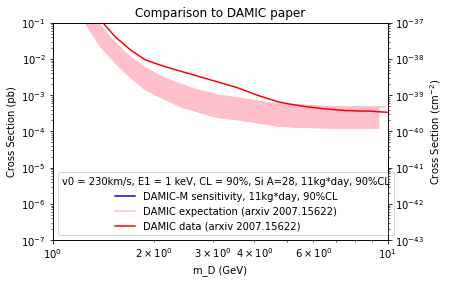

In [14]:
plt.figure(figsize=(8, 10))
fig, ax1 = plt.subplots()
ax1.plot(mass1, xs1, label='DAMIC-M sensitivity, 11kg*day, 90%CL', color='blue')
# ax1.plot(mass1, xs1, label='DAMIC-M sensitivity (+bkg_model), 11kg*day, 90%CL', color='blue')
ax1.plot(mass2, xs2, color='pink')
# ax1.plot(mass2, xs2, label='DAMIC expectation', color='pink')

ax1.plot(mass3, xs3, label='DAMIC expectation (arxiv 2007.15622)', color='pink')
ax1.plot(mass4, xs4, label='DAMIC data (arxiv 2007.15622)', color='red')

common_mass = np.linspace(max(min(mass2), min(mass3)), min(max(mass2), max(mass3)), 500)
xs2_interp = np.interp(common_mass, mass2, xs2)
xs3_interp = np.interp(common_mass, mass3, xs3)
ax1.fill_between(common_mass, xs2_interp, xs3_interp, color='pink', alpha=1)

ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('Comparison to DAMIC paper')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('Cross Section (pb)')
ax1.set_xlim(1,10)
ax1.set_ylim(1e-7,1e-1)

ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")

# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

ax1.legend(title='v0 = 230km/s, E1 = 1 keV, CL = 90%, Si A=28, 11kg*day, 90%CL')
plt.show()